# Appropriate-reliance analysis ("is it just automation bias?")

Distinguishes genuine, selective reliance from indiscriminate deference to the LLM.

**Metrics** (Schemmer et al. 2023, *Appropriate Reliance on AI*, CHI), computed on
physician–LLM disagreements:

- **RAIR** — Relative AI Reliance: among cases where the physician's *unaided* answer
  was wrong and the LLM was right, the fraction where the physician adopted the correct
  answer. *(take good advice)*
- **RSR** — Relative Self-Reliance: among cases where the physician was right and the LLM
  wrong, the fraction where the physician kept a correct final answer. *(resist bad advice)*

Appropriate reliance = high on **both**; automation bias = high RAIR with **low** RSR.
Also reports the complementarity test (human+RAG vs LLM-alone) and the selective-adherence
test. CIs are cluster bootstrap over participants (`pid`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, norm
import statsmodels.genmod.bayes_mixed_glm as bglm

# ── Config ───────────────────────────────────────────────────────────
RESPONSES = "../results/reader_study/responses.csv"
OUT       = "../plots/reader_study/reliance_quadrant.png"   # set None to skip saving
N_BOOT    = 10000
SEED      = 12345

# ── Load ─────────────────────────────────────────────────────────
df = pd.read_csv(RESPONSES)
df = df[df["answered"]].copy()

ini   = df["initial_correct"].to_numpy(bool)   # unaided (pre-RAG)
fin   = df["final_correct"].to_numpy(bool)      # assisted (post-RAG)
llm   = df["llm_is_correct"].to_numpy(bool)
adopt = df["final_eq_llm"].to_numpy(bool)        # final answer == LLM's answer
pid   = df["pid"].to_numpy()

# Schemmer decision-relevant quadrants (physician & LLM necessarily disagree)
qA = (~ini) &  llm   # unaided wrong, LLM right  -> should adopt   (RAIR)
qB =  ini  & (~llm)  # unaided right, LLM wrong  -> should self-rely (RSR)

print(f"N = {len(df)} answered questions, {df['pid'].nunique()} physicians")
print(f"RAIR quadrant (unaided wrong & LLM right): {qA.sum()}")
print(f"RSR  quadrant (unaided right & LLM wrong): {qB.sum()}")

N = 736 answered questions, 46 physicians
RAIR quadrant (unaided wrong & LLM right): 171
RSR  quadrant (unaided right & LLM wrong): 48


## Point estimates + cluster bootstrap

In [2]:
def metrics(ini, fin, llm, adopt):
    """All reliance metrics on a (sub)sample."""
    a = (~ini) & llm            # RAIR denominator
    b =  ini  & (~llm)          # RSR  denominator
    return {
        "acc_unaided":  ini.mean(),
        "acc_assisted": fin.mean(),
        "acc_llm":      llm.mean(),
        "rair":         adopt[a].mean() if a.sum() else np.nan,   # adopt correct advice
        "rsr":          fin[b].mean()   if b.sum() else np.nan,   # keep correct answer
        "adopt_wrong":  adopt[b].mean() if b.sum() else np.nan,   # adopt incorrect advice
    }

pt = metrics(ini, fin, llm, adopt)

# ── cluster bootstrap over participants ──────────────────────────────────
pids = np.unique(pid)
idx_by_pid = {p: np.where(pid == p)[0] for p in pids}
rng = np.random.default_rng(SEED)
keys = ["acc_unaided", "acc_assisted", "acc_llm", "rair", "rsr", "adopt_wrong"]
boot = {k: [] for k in keys}
for _ in range(N_BOOT):
    draw = rng.choice(pids, size=len(pids), replace=True)
    rows = np.concatenate([idx_by_pid[p] for p in draw])
    m = metrics(ini[rows], fin[rows], llm[rows], adopt[rows])
    for k in keys:
        boot[k].append(m[k])
boot = {k: np.array(v, float) for k, v in boot.items()}

def ci(k):
    a = boot[k][~np.isnan(boot[k])]
    return np.percentile(a, 2.5), np.percentile(a, 97.5)

def show(label, k):
    lo, hi = ci(k)
    print(f"  {label:<34} {pt[k]*100:5.1f}%   95% CI [{lo*100:4.1f}, {hi*100:4.1f}]")

print("Accuracy")
show("Physician unaided", "acc_unaided")
show("Physician + RAG",   "acc_assisted")
show("LLM (RAG) alone",   "acc_llm")
print("\nAppropriate reliance (Schemmer et al. 2023)")
show("RAIR  (adopt good advice)", "rair")
show("RSR   (resist bad advice)", "rsr")

Accuracy
  Physician unaided                   70.8%   95% CI [67.0, 74.5]
  Physician + RAG                     82.6%   95% CI [80.2, 85.2]
  LLM (RAG) alone                     87.5%   95% CI [87.5, 87.5]

Appropriate reliance (Schemmer et al. 2023)
  RAIR  (adopt good advice)           64.3%   95% CI [56.9, 71.4]
  RSR   (resist bad advice)           64.6%   95% CI [51.0, 78.4]


## Complementarity vs LLM-alone (McNemar)

In [3]:
b = int((fin & ~llm).sum())   # team right, LLM wrong  (physician saves)
c = int((~fin & llm).sum())   # team wrong, LLM right  (physician drag-down)
p_mcnemar = binomtest(min(b, c), b + c, 0.5).pvalue if (b + c) else np.nan
print("Complementarity vs LLM-alone (exact McNemar, discordant pairs)")
print(f"  team right / LLM wrong (saves):     {b}")
print(f"  team wrong / LLM right (drag-down):  {c}")
print(f"  exact McNemar p = {p_mcnemar:.4g}")

Complementarity vs LLM-alone (exact McNemar, discordant pairs)
  team right / LLM wrong (saves):     31
  team wrong / LLM right (drag-down):  67
  exact McNemar p = 0.0003545


## Selective adherence: do physicians adopt the LLM more when it is correct?

Restricted to the two decision-relevant quadrants (A = should adopt, B = should self-rely).
Automation bias predicts adoption *independent* of LLM correctness (OR ≈ 1).

In [4]:
p_right = adopt[qA].mean()   # == RAIR
p_wrong = adopt[qB].mean()   # adoption of INCORRECT advice
print("Selective adherence (Schemmer quadrants A & B)")
print(f"  adopt LLM | LLM correct : {p_right*100:5.1f}%  ({adopt[qA].sum()}/{qA.sum()})   = RAIR")
print(f"  adopt LLM | LLM wrong   : {p_wrong*100:5.1f}%  ({adopt[qB].sum()}/{qB.sum()})")
print(f"  risk difference         : {(p_right-p_wrong)*100:5.1f} pts")
print(f"  odds ratio              : {(p_right/(1-p_right))/(p_wrong/(1-p_wrong)):5.2f}x")

# mixed-effects logistic regression (random intercept per physician)
d = df[qA | qB].copy()
d["adopt"]       = adopt[qA | qB].astype(int)
d["llm_correct"] = llm[qA | qB].astype(int)
glmm = bglm.BinomialBayesMixedGLM.from_formula(
    "adopt ~ llm_correct", {"a": "0 + C(pid)"}, d).fit_vb()
beta, se = glmm.fe_mean[1], glmm.fe_sd[1]
z = beta / se
p = 2 * (1 - norm.cdf(abs(z)))
print("\nMixed-effects logistic (random intercept per physician)")
print(f"  llm_correct log-OR = {beta:.3f} (SE {se:.3f}); OR = {np.exp(beta):.2f}; z = {z:.2f}, p = {p:.2g}")

# bootstrap CI on the risk difference
diff = boot["rair"] - boot["adopt_wrong"]
dlo, dhi = np.percentile(diff[~np.isnan(diff)], [2.5, 97.5])
print(f"  bootstrap risk-difference 95% CI: [{dlo*100:.1f}, {dhi*100:.1f}] pts")

Selective adherence (Schemmer quadrants A & B)
  adopt LLM | LLM correct :  64.3%  (110/171)   = RAIR
  adopt LLM | LLM wrong   :  33.3%  (16/48)
  risk difference         :  31.0 pts
  odds ratio              :  3.61x

Mixed-effects logistic (random intercept per physician)
  llm_correct log-OR = 1.307 (SE 0.162); OR = 3.69; z = 8.05, p = 8.9e-16
  bootstrap risk-difference 95% CI: [16.8, 45.4] pts


## RAIR-vs-RSR quadrant figure

PLOT_SUBSET = 'all': 736 answered questions, 46 physicians  (RAIR n=171, RSR n=48)


saved -> ../plots/reader_study/reliance_quadrant.png


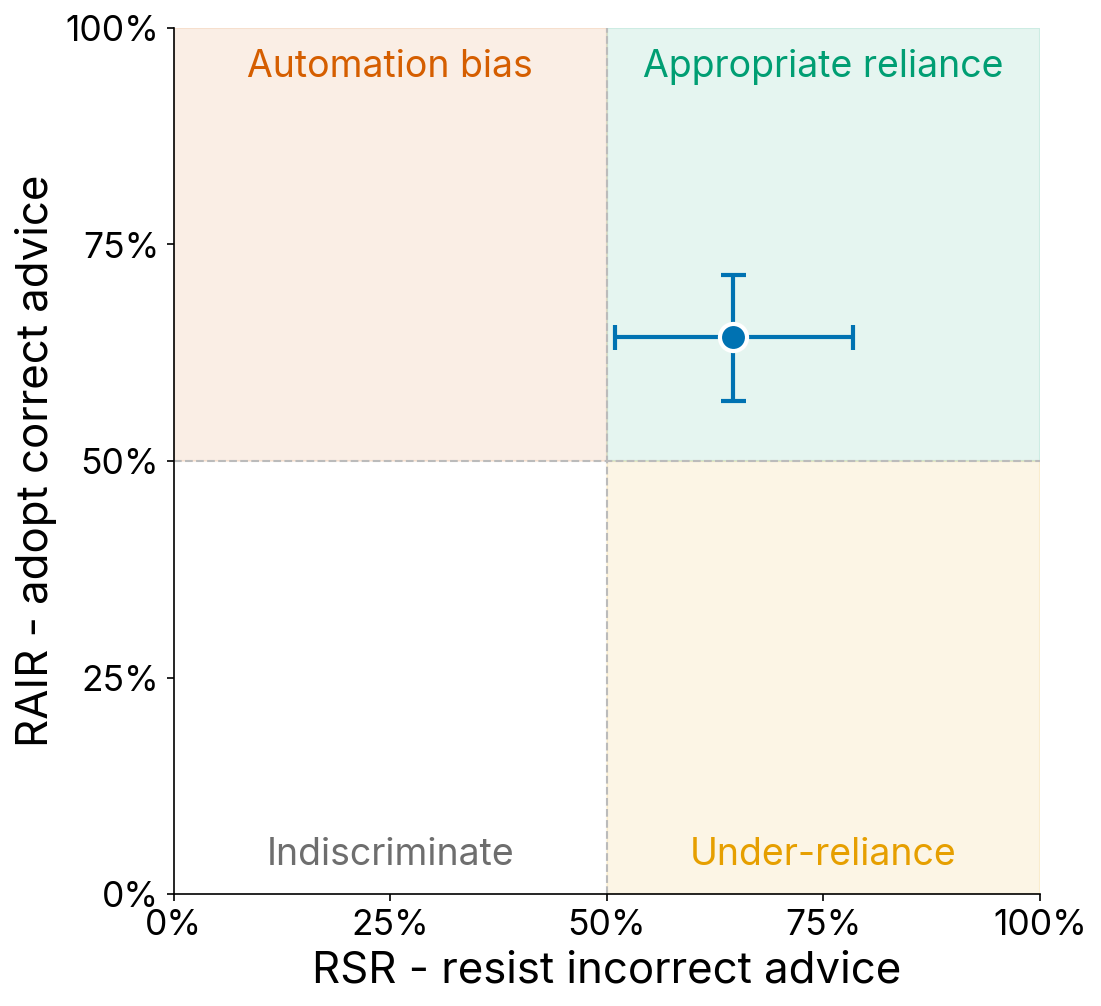

In [5]:
# ── Which questions go into the quadrant plot ────────────────────────────────────────
# "all"      -> every answered question (the preregistered overall analysis)
# "clinical" -> diagnosis / treatment / prognosis question_types only
PLOT_SUBSET = "all"          # "all" | "clinical"
_CLINICAL_QTYPES = ["diagnosis", "treatment", "prognosis"]

# Row mask + display strings for the chosen subset.
if PLOT_SUBSET == "clinical":
    _sub_mask  = df["question_type"].isin(_CLINICAL_QTYPES).to_numpy()
    _sub_label = "Physicians + RAG\n(diagnosis / treatment / prognosis)"
    _out_path  = OUT.replace(".png", "_clinical.png") if OUT is not None else None
elif PLOT_SUBSET == "all":
    _sub_mask  = np.ones(len(df), bool)
    _sub_label = "Physicians + RAG"
    _out_path  = OUT
else:
    raise ValueError(f"PLOT_SUBSET must be 'all' or 'clinical', got {PLOT_SUBSET!r}")

# Recompute point estimates + cluster bootstrap on the chosen subset. When PLOT_SUBSET
# == "all" these reproduce the module-level pt / boot exactly; the subset case is what
# this cell adds. Local names (_pt / _boot / _ci) so the exploratory cells below keep
# using the full-sample pt / boot / ci.
_ini, _fin, _llm = ini[_sub_mask], fin[_sub_mask], llm[_sub_mask]
_adopt, _pid     = adopt[_sub_mask], pid[_sub_mask]
_pt = metrics(_ini, _fin, _llm, _adopt)

_pids       = np.unique(_pid)
_idx_by_pid = {p: np.where(_pid == p)[0] for p in _pids}
_rng = np.random.default_rng(SEED)
_bkeys = ["rair", "rsr"]
_boot = {k: [] for k in _bkeys}
for _ in range(N_BOOT):
    _draw = _rng.choice(_pids, size=len(_pids), replace=True)
    _rows = np.concatenate([_idx_by_pid[p] for p in _draw])
    _m = metrics(_ini[_rows], _fin[_rows], _llm[_rows], _adopt[_rows])
    for k in _bkeys:
        _boot[k].append(_m[k])
_boot = {k: np.array(v, float) for k, v in _boot.items()}

def _ci(k):
    a = _boot[k][~np.isnan(_boot[k])]
    return np.percentile(a, 2.5), np.percentile(a, 97.5)

_qA_n = int(((~_ini) &  _llm).sum())
_qB_n = int(( _ini  & ~_llm).sum())
print(f"PLOT_SUBSET = {PLOT_SUBSET!r}: {_sub_mask.sum()} answered questions, "
      f"{len(_pids)} physicians  (RAIR n={_qA_n}, RSR n={_qB_n})")

# ── Figure style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter Variable", "Inter", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 15,                       # bumped up (was 12) for a legible print panel
    "figure.facecolor": "white", "axes.facecolor": "white",
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "pdf.fonttype": 42, "ps.fonttype": 42,
})
# Colour-blind-safe Okabe-Ito palette (validated: worst quadrant/marker pair ΔE 11.0
# for deuteranopia, well clear of the 8-point floor). Quadrant identity is *also* carried
# by position and by the text labels, so hue never stands alone. The point/CI blue
# (#0072B2) is close to the citation-support panels' blue, so the figures still read as
# one system.
C_GOOD, C_BAD, C_MEH, C_IND = "#009E73", "#D55E00", "#E69F00", "#6E6E6E"   # green/vermillion/amber/gray
C_PT, T = "#0072B2", "#1A1A1A"                                             # estimate + CI blue; ink

rair_pt, rsr_pt = _pt["rair"], _pt["rsr"]
rair_ci, rsr_ci = _ci("rair"), _ci("rsr")

# Height 6 matches the citation-support figure below so the two line up side by side.
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.axhspan(0.5, 1, xmin=0.5, xmax=1, color=C_GOOD, alpha=0.10)   # TR appropriate
ax.axhspan(0.5, 1, xmin=0,   xmax=0.5, color=C_BAD,  alpha=0.10)  # TL automation bias
ax.axhspan(0,   0.5, xmin=0.5, xmax=1, color=C_MEH,  alpha=0.10)  # BR under-reliance
ax.axvline(0.5, color="#BBBBBB", lw=1, ls="--", zorder=1)
ax.axhline(0.5, color="#BBBBBB", lw=1, ls="--", zorder=1)

for x, y, t, c in [
    (0.75, 0.955, "Appropriate reliance", C_GOOD),
    (0.25, 0.955, "Automation bias", C_BAD),
    (0.75, 0.045, "Under-reliance", C_MEH),
    (0.25, 0.045, "Indiscriminate", C_IND),
]:
    ax.text(x, y, t, ha="center", va="center", fontsize=18,
            fontweight="bold", color=c, zorder=2)

# Point estimate with cluster-bootstrap 95% CI whiskers (white-edged marker on top).
ax.errorbar(rsr_pt, rair_pt,
            xerr=[[rsr_pt - rsr_ci[0]], [rsr_ci[1] - rsr_pt]],
            yerr=[[rair_pt - rair_ci[0]], [rair_ci[1] - rair_pt]],
            fmt="o", ms=13, color=C_PT, ecolor=C_PT,
            elinewidth=2.0, capsize=6, capthick=2.0, mec="white", mew=2.0, zorder=5)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("RSR - resist incorrect advice", fontsize=21, fontweight="600")
ax.set_ylabel("RAIR - adopt correct advice", fontsize=21, fontweight="600")
ticks = np.arange(0, 1.01, 0.25)
tick_labels = [f"{t*100:.0f}%" for t in ticks]
ax.set_xticks(ticks); ax.set_xticklabels(tick_labels)
ax.set_yticks(ticks); ax.set_yticklabels(tick_labels)
ax.tick_params(labelsize=17)
ax.set_aspect("equal")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

if _out_path is not None:
    import os
    os.makedirs(os.path.dirname(_out_path), exist_ok=True)
    fig.savefig(_out_path)
    print(f"saved -> {_out_path}")
plt.show()

## EXPLORATORY (not preregistered): RAIR / RSR stratified by CORA citation-support level

> **This analysis is EXPLORATORY and sits OUTSIDE the preregistered confirmatory
> hypothesis family (A1/B1/C1).** No confirmatory p-values are reported; effects are
> summarized with 95% CIs only and treated as hypothesis-generating.

Each physician×question decision is split by whether CORA's cited sources supported its
advice, using **the focal physician's own source ratings** — a binary contrast of
**no citation support** (`n_support == 0`: none of CORA's cited sources rated "Supports")
vs **any citation support** (`n_support >= 1`: at least one source rated "Supports"). This
is the `any_source_supports` column. RAIR and RSR are recomputed **within** the
any- and no-support strata, keeping the **same Schemmer conflict subsets** as the overall
metrics (`qA` for RAIR, `qB` for RSR). A pooled-strata reconciliation assertion guarantees
any + no recover the overall values.

**Interpretive focus**
- **RAIR by support** — on the CORA-*correct* conflict subset (`qA`: unaided wrong, LLM
  right): does citation support increase appropriate switching *to* CORA?
  *(expectation: support helps.)*
- **RSR by support** — on the CORA-*wrong* conflict subset (`qB`: unaided right, LLM
  wrong): does citation support **depress** appropriate self-reliance — i.e. do
  physicians abandon their own correct answer more often when the *wrong* advice is
  *cited at all*? **An RSR collapse under any support is the "confident-but-wrong grounding
  miscalibrates trust" finding, and is the point of this analysis.**

**Caveats.** The stratifier is the focal physician's *own* rating, so it reflects
*perceived* (not independent) citation support. The CORA-wrong subset (`qB`) is small, so
any stratum with denominator < `MIN_DENOM` (10) is flagged as too small for stable
estimation. A threshold-sensitivity check (any / majority / unanimous) further down
confirms the direction is stable. Reliability of the support rating (Gwet's AC1 across
raters) is reported alongside the table.

In [6]:
import math, os

# ── Stratifier: does ANY of CORA's cited sources support its advice? ──────────────────
# Binary split on the focal physician's OWN source ratings (per physician×question):
#   ANY support = n_support >= 1  -> >=1 of CORA's cited sources rated "Supports"
#   NO  support = n_support == 0  -> physician rated NONE of the cited sources "Supports"
# This is exactly the `any_source_supports` column (equivalent to a precision cut just
# above 0). `hi` = ANY support, `lo` = NO support (names kept for the downstream code).
MIN_DENOM = 10                        # strata with denominator < this are flagged unstable

# Per-row citation precision (fraction of rated sources marked "Supports"); no longer the
# stratifier, but kept because the threshold-sensitivity robustness check below reuses it.
precision = (df["n_support"] / df["n_support_rated"]).to_numpy(float)   # per row, 0..1
assert not np.isnan(precision).any(), "precision has NaN -> pooled reconciliation would break"

# ── Binary stratifier: ANY vs NO citation support ────────────────────────────────────
any_support = (df["n_support"].to_numpy() >= 1)      # >=1 cited source rated "Supports"
hi, lo = any_support, ~any_support                    # hi = any support, lo = no support
df["citation_support_high"] = hi                      # 'high' == any support (name kept)
STRATIFIER_LABEL = "any cited source supports (n_support >= 1)"
assert (hi | lo).all() and not (hi & lo).any(), "strata must partition all rows exactly"

print(f"Stratifier: {STRATIFIER_LABEL}   -- ANY vs NO citation support")
print(f"  any-support rows: {int(hi.sum()):4d}   no-support rows: {int(lo.sum()):4d}")
print(f"  RAIR subset qA -> any {int((qA & hi).sum())} / none {int((qA & lo).sum())}")
print(f"  RSR  subset qB -> any {int((qB & hi).sum())} / none {int((qB & lo).sum())}   "
      f"(CORA-wrong subset is small)")

# ── CI helpers ───────────────────────────────────────────────────────────────────────
def wilson(k, n, z=1.96):
    """Wilson score 95% CI for a binomial proportion; returns (p, lo, hi)."""
    if n == 0:
        return (np.nan, np.nan, np.nan)
    p = k / n; d = 1 + z*z/n
    centre = (p + z*z/(2*n)) / d
    half = z * math.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return p, max(0.0, centre - half), min(1.0, centre + half)

def newcombe_diff(k1, n1, k2, n2, z=1.96):
    """Newcombe (1998) method 10 hybrid-score 95% CI for p1 - p2 (independent props)."""
    if n1 == 0 or n2 == 0:
        return (np.nan, np.nan, np.nan)
    p1, l1, u1 = wilson(k1, n1, z)
    p2, l2, u2 = wilson(k2, n2, z)
    d = p1 - p2
    return d, d - math.sqrt((p1 - l1)**2 + (u2 - p2)**2), d + math.sqrt((u1 - p1)**2 + (p2 - l2)**2)

Stratifier: any cited source supports (n_support >= 1)   -- ANY vs NO citation support
  any-support rows:  568   no-support rows:  168
  RAIR subset qA -> any 121 / none 50
  RSR  subset qB -> any 23 / none 25   (CORA-wrong subset is small)


In [7]:
# ── Per-stratum RAIR / RSR on the SAME conflict subsets (reuses metrics(), qA, qB) ───
# RAIR numerator = `adopt` (final == LLM) on qA;  RSR numerator = `fin` (final correct)
# on qB — identical to metrics() above; we only restrict rows to a support stratum.
# stratum "high" == ANY citation support;  "low" == NO citation support.
def stratum_counts(mask):
    return {"rair": (int(adopt[qA & mask].sum()), int((qA & mask).sum())),
            "rsr":  (int(fin[qB & mask].sum()),   int((qB & mask).sum()))}

strata = {"high": hi, "low": lo}
rows = []
for s, mask in strata.items():
    m = metrics(ini[mask], fin[mask], llm[mask], adopt[mask])   # cross-check via reused fn
    cnt = stratum_counts(mask)
    for metric in ("rair", "rsr"):
        num, den = cnt[metric]
        est, clo, chi = wilson(num, den)
        if den:
            assert abs(est - m[metric]) < 1e-9, f"{metric}/{s} disagrees with metrics()"
        rows.append({"analysis": "EXPLORATORY (not preregistered)",
                     "stratifier": STRATIFIER_LABEL,
                     "metric": metric.upper(), "stratum": s,
                     "numerator": num, "denominator": den,
                     "estimate": est, "wilson_lo": clo, "wilson_hi": chi,
                     "too_small": den < MIN_DENOM})
strat_tbl = pd.DataFrame(rows)

# ── Reconciliation: pooled strata MUST equal the notebook's overall RAIR / RSR ───────
for metric, key, onum, oden in [("RAIR", "rair", int(adopt[qA].sum()), int(qA.sum())),
                                 ("RSR",  "rsr",  int(fin[qB].sum()),   int(qB.sum()))]:
    sub = strat_tbl[strat_tbl.metric == metric]
    pnum, pden = int(sub.numerator.sum()), int(sub.denominator.sum())
    assert pnum == onum, f"{metric} numerator {pnum} != overall {onum}"
    assert pden == oden, f"{metric} denominator {pden} != overall {oden}"
    assert abs(pnum / pden - pt[key]) < 1e-9, f"{metric} pooled estimate != overall pt[{key}]"
print("Reconciliation OK: any + no support pool EXACTLY to the overall RAIR / RSR.\n")

_stratum_name = {"high": "any", "low": "none"}
_disp = strat_tbl.copy()
_disp["stratum"] = _disp["stratum"].map(_stratum_name)
with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
    print(_disp[["metric", "stratum", "numerator", "denominator",
                 "estimate", "wilson_lo", "wilson_hi", "too_small"]].to_string(index=False))

Reconciliation OK: any + no support pool EXACTLY to the overall RAIR / RSR.

metric stratum  numerator  denominator  estimate  wilson_lo  wilson_hi  too_small
  RAIR     any         93          121     0.769      0.686      0.835      False
   RSR     any          8           23     0.348      0.188      0.551      False
  RAIR    none         17           50     0.340      0.224      0.478      False
   RSR    none         23           25     0.920      0.750      0.978      False


In [8]:
# ── Reader-clustered bootstrap (resample physicians) for each stratum + the diffs ────
# Items are nested within readers and the strata are small, so we resample whole
# physicians (matching the overall analysis' clustering) and recompute RAIR/RSR within
# the high & low strata on each replicate. Complements the Wilson CIs above.
def strat_estimates(ridx):
    m_hi = hi[ridx]; m_lo = lo[ridx]; qA_r = qA[ridx]; qB_r = qB[ridx]
    ad = adopt[ridx]; fn = fin[ridx]; out = {}
    for name, sub in [("high", m_hi), ("low", m_lo)]:
        da = qA_r & sub; db = qB_r & sub
        out[f"rair_{name}"] = ad[da].mean() if da.sum() else np.nan
        out[f"rsr_{name}"]  = fn[db].mean() if db.sum() else np.nan
    out["rair_diff"] = out["rair_high"] - out["rair_low"]
    out["rsr_diff"]  = out["rsr_high"]  - out["rsr_low"]
    return out

rng2 = np.random.default_rng(SEED)   # independent stream; same clustering as overall
bkeys = ["rair_high", "rair_low", "rsr_high", "rsr_low", "rair_diff", "rsr_diff"]
sboot = {k: [] for k in bkeys}
for _ in range(N_BOOT):
    draw = rng2.choice(pids, size=len(pids), replace=True)
    ridx = np.concatenate([idx_by_pid[p] for p in draw])
    e = strat_estimates(ridx)
    for k in bkeys:
        sboot[k].append(e[k])
sboot = {k: np.array(v, float) for k, v in sboot.items()}

def boot_ci(k):
    a = sboot[k][~np.isnan(sboot[k])]
    if a.size == 0:
        return (np.nan, np.nan, np.nan)
    return a.mean(), np.percentile(a, 2.5), np.percentile(a, 97.5)

print("Reader-clustered bootstrap (resample physicians), 95% percentile CI:")
for k in bkeys:
    mean_, lo_, hi_ = boot_ci(k)
    nanf = np.isnan(sboot[k]).mean()
    tag = f"   [{nanf*100:.0f}% replicates had an empty stratum]" if nanf > 0.01 else ""
    print(f"  {k:<10} {mean_*100:6.1f}%   95% CI [{lo_*100:6.1f}, {hi_*100:6.1f}]{tag}")

# attach the reader-bootstrap CIs to each stratum row of the table
_bmap = {("RAIR", "high"): "rair_high", ("RAIR", "low"): "rair_low",
         ("RSR", "high"): "rsr_high",  ("RSR", "low"): "rsr_low"}
strat_tbl["boot_lo"] = np.nan; strat_tbl["boot_hi"] = np.nan
for i, r in strat_tbl.iterrows():
    _, blo, bhi = boot_ci(_bmap[(r["metric"], r["stratum"])])
    strat_tbl.at[i, "boot_lo"] = blo; strat_tbl.at[i, "boot_hi"] = bhi

Reader-clustered bootstrap (resample physicians), 95% percentile CI:
  rair_high    76.9%   95% CI [  67.8,   84.9]
  rair_low     34.0%   95% CI [  20.8,   47.7]
  rsr_high     34.8%   95% CI [  17.2,   52.6]
  rsr_low      91.9%   95% CI [  79.2,  100.0]
  rair_diff    42.9%   95% CI [  26.3,   58.7]
  rsr_diff    -57.1%   95% CI [ -76.9,  -35.7]


In [9]:
# ── Between-stratum difference (high - low): Newcombe + reader-bootstrap CIs ─────────
# NO confirmatory p-value (this family is exploratory).
print("High-minus-low difference (exploratory; no confirmatory p-value):")
diff_rows = []
for metric in ("RAIR", "RSR"):
    sub = strat_tbl[strat_tbl.metric == metric].set_index("stratum")
    kh, nh = int(sub.loc["high", "numerator"]), int(sub.loc["high", "denominator"])
    kl, nl = int(sub.loc["low",  "numerator"]), int(sub.loc["low",  "denominator"])
    d, nlo, nhi = newcombe_diff(kh, nh, kl, nl)          # Newcombe method 10
    _, blo, bhi = boot_ci("rair_diff" if metric == "RAIR" else "rsr_diff")
    flag = "  [stratum n<10 -> unstable]" if (nh < MIN_DENOM or nl < MIN_DENOM) else ""
    print(f"  {metric}: high {kh}/{nh} - low {kl}/{nl} = {d*100:+5.1f} pts"
          f"   Newcombe 95% CI [{nlo*100:+5.1f}, {nhi*100:+5.1f}]"
          f"   reader-boot 95% CI [{blo*100:+5.1f}, {bhi*100:+5.1f}]{flag}")
    diff_rows.append({"metric": metric, "diff_high_minus_low": d,
                      "newcombe_lo": nlo, "newcombe_hi": nhi,
                      "boot_lo": blo, "boot_hi": bhi, "high_n": nh, "low_n": nl})
diff_tbl = pd.DataFrame(diff_rows)

# ── Threshold sensitivity — is the DIRECTION of the RSR effect stable? ───────────────
# any (>=1 source) == any_source_supports;  unanimous (all) == all_sources_support.
print("\nThreshold sensitivity (RSR is the finding of interest):")
SENS = [("any (>=1 source)", 1e-9), ("majority (>=50%)", 0.5), ("unanimous (all)", 1.0)]
def _rr(metric_arr, q, mask):
    den = int((q & mask).sum()); num = int(metric_arr[q & mask].sum())
    return num, den, (num / den if den else np.nan)
sens_rows = []
for label, thr in SENS:
    mh = precision >= thr; ml = ~mh
    _, rhd, rh = _rr(adopt, qA, mh); _, rld, rl = _rr(adopt, qA, ml)
    _, shd, sh = _rr(fin,   qB, mh); _, sld, sl = _rr(fin,   qB, ml)
    sens_rows.append({"threshold": label, "cut": thr,
        "RAIR_high": rh, "RAIR_high_n": rhd, "RAIR_low": rl, "RAIR_low_n": rld,
        "RAIR_diff": rh - rl,
        "RSR_high": sh, "RSR_high_n": shd, "RSR_low": sl, "RSR_low_n": sld,
        "RSR_diff": sh - sl})
sens_tbl = pd.DataFrame(sens_rows)
print(sens_tbl[["threshold", "RSR_high", "RSR_high_n", "RSR_low", "RSR_low_n",
                "RSR_diff", "RAIR_diff"]].to_string(index=False))
signs = np.sign(sens_tbl["RSR_diff"].dropna())
stable = (len(signs) > 0) and (signs.nunique() == 1)
direction = ("negative = RSR collapse under high support" if (stable and signs.iloc[0] < 0)
             else "positive" if stable else "mixed")
print(f"\nRSR high-minus-low direction across thresholds: "
      f"{'STABLE' if stable else 'NOT stable'} ({direction}); "
      f"values = {list(sens_tbl['RSR_diff'].round(3))}")

High-minus-low difference (exploratory; no confirmatory p-value):
  RAIR: high 93/121 - low 17/50 = +42.9 pts   Newcombe 95% CI [+26.7, +56.2]   reader-boot 95% CI [+26.3, +58.7]
  RSR: high 8/23 - low 23/25 = -57.2 pts   Newcombe 95% CI [-74.2, -30.7]   reader-boot 95% CI [-76.9, -35.7]

Threshold sensitivity (RSR is the finding of interest):
       threshold  RSR_high  RSR_high_n  RSR_low  RSR_low_n  RSR_diff  RAIR_diff
any (>=1 source)  0.347826          23 0.920000         25 -0.572174   0.428595
majority (>=50%)  0.380952          21 0.851852         27 -0.470899   0.359937
 unanimous (all)  0.375000           8 0.700000         40 -0.325000   0.248733

RSR high-minus-low direction across thresholds: STABLE (negative = RSR collapse under high support); values = [-0.572, -0.471, -0.325]


In [10]:
# ── Gwet's AC1 for the citation-support rating (reliability of the STRATIFIER) ───────
# Computed HERE (searched the repo — not found precomputed anywhere).
# Unit: question-level binary `any_source_supports` (>=1 of CORA's cited sources rated
# "Supports"), rated by the physicians who saw that question. Restricted to questions
# with >=2 raters. Standard Gwet (2008) AC1 for binary labels, multiple raters, unequal
# rater counts per subject:  AC1 = (pa - pe) / (1 - pe).
def gwet_ac1_binary(subject_ratings):
    K = 2
    pas, pis, used = [], [], 0
    for r in subject_ratings:
        r = np.asarray(r, float); r = r[~np.isnan(r)]; ri = r.size
        if ri < 2:                       # need >=2 raters to observe agreement
            continue
        used += 1
        n1 = r.sum(); n0 = ri - n1        # per-category counts
        pas.append((n1*(n1-1) + n0*(n0-1)) / (ri*(ri-1)))   # per-subject agreement
        pis.append(n1 / ri)                                  # per-subject P(category=1)
    if used == 0:
        return np.nan, 0
    pa  = np.mean(pas)
    pi1 = np.mean(pis)
    pe  = (pi1*(1-pi1) + (1-pi1)*pi1) / (K-1)   # = 2*pi1*(1-pi1) for K=2
    return ((pa - pe) / (1 - pe) if pe < 1 else np.nan), used

q_ratings = (df.groupby("question_id")["any_source_supports"]
               .apply(lambda s: s.astype(float).to_numpy()))
ac1, n_used = gwet_ac1_binary(list(q_ratings))
print("Citation-support IRR (computed here) — Gwet's AC1 on 'any_source_supports':")
print(f"  AC1 = {ac1:.3f}   over {n_used} of {q_ratings.size} questions rated by >=2 physicians")
print(f"  (category: >=1 of CORA's cited sources supports the answer)")

Citation-support IRR (computed here) — Gwet's AC1 on 'any_source_supports':
  AC1 = 0.683   over 256 of 288 questions rated by >=2 physicians
  (category: >=1 of CORA's cited sources supports the answer)


In [11]:
# ── Save results + readable summary ─────────────────────────────────────────────────
OUTDIR = "../results/reader_study"
os.makedirs(OUTDIR, exist_ok=True)
strat_csv = f"{OUTDIR}/reliance_by_citation_support.csv"
diff_csv  = f"{OUTDIR}/reliance_by_citation_support_diffs.csv"
sens_csv  = f"{OUTDIR}/reliance_by_citation_support_sensitivity.csv"

strat_out = strat_tbl.copy()
strat_out["citation_support_stratifier"] = STRATIFIER_LABEL
strat_out["gwet_ac1_any_support"] = ac1
strat_out.to_csv(strat_csv, index=False)
diff_tbl.to_csv(diff_csv, index=False)
sens_tbl.to_csv(sens_csv, index=False)

_stratum_name = {"high": "any ", "low": "none"}   # display-only relabel of hi/lo

def _p(x):
    return "  n/a" if (x is None or (isinstance(x, float) and np.isnan(x))) else f"{x*100:5.1f}%"

print("=" * 80)
print("EXPLORATORY (NOT preregistered): RAIR / RSR by CORA citation-support level")
print("=" * 80)
print(f"Stratifier : ANY vs NO citation support -- {STRATIFIER_LABEL}")
print(f"             (physician's OWN source ratings; n_support >= 1 vs == 0)")
print(f"Support IRR: Gwet's AC1 = {ac1:.3f} on 'any_source_supports' "
      f"({n_used} questions, >=2 raters)  [computed here; not found precomputed]")
print(f"Conflict subsets (unchanged): RAIR on qA n={int(qA.sum())}, "
      f"RSR on qB n={int(qB.sum())}  <-- CORA-wrong subset is SMALL")
print("-" * 80)
for metric in ("RAIR", "RSR"):
    print(f"{metric}:")
    for _, r in strat_tbl[strat_tbl.metric == metric].iterrows():
        flag = "   <-- n<10: TOO SMALL for stable estimation" if r.too_small else ""
        print(f"  {_stratum_name[r.stratum]} {int(r.numerator):3d}/{int(r.denominator):3d} = {_p(r.estimate)}"
              f"   Wilson [{_p(r.wilson_lo)},{_p(r.wilson_hi)}]"
              f"   reader-boot [{_p(r.boot_lo)},{_p(r.boot_hi)}]{flag}")
    dr = diff_tbl[diff_tbl.metric == metric].iloc[0]
    print(f"  any-none: {dr.diff_high_minus_low*100:+5.1f} pts"
          f"   Newcombe [{dr.newcombe_lo*100:+.1f},{dr.newcombe_hi*100:+.1f}]"
          f"   reader-boot [{dr.boot_lo*100:+.1f},{dr.boot_hi*100:+.1f}]")
print("-" * 80)
rsr_dir = diff_tbl.set_index("metric").loc["RSR", "diff_high_minus_low"]
print("Interpretation (RSR is the target of this analysis):")
if rsr_dir < 0:
    print("  RSR is LOWER when >=1 source supports -> consistent with well-cited WRONG advice")
    print("  DEPRESSING appropriate self-reliance ('confident-but-wrong grounding miscalibrates")
    print("  trust'). Hypothesis-generating only: qB strata are small; see sensitivity + IRR.")
else:
    print("  RSR is NOT lower under any citation support in this sample; no RSR-collapse signal here.")
print(f"\nSaved:\n  {strat_csv}\n  {diff_csv}\n  {sens_csv}")

EXPLORATORY (NOT preregistered): RAIR / RSR by CORA citation-support level
Stratifier : ANY vs NO citation support -- any cited source supports (n_support >= 1)
             (physician's OWN source ratings; n_support >= 1 vs == 0)
Support IRR: Gwet's AC1 = 0.683 on 'any_source_supports' (256 questions, >=2 raters)  [computed here; not found precomputed]
Conflict subsets (unchanged): RAIR on qA n=171, RSR on qB n=48  <-- CORA-wrong subset is SMALL
--------------------------------------------------------------------------------
RAIR:
  any   93/121 =  76.9%   Wilson [ 68.6%, 83.5%]   reader-boot [ 67.8%, 84.9%]
  none  17/ 50 =  34.0%   Wilson [ 22.4%, 47.8%]   reader-boot [ 20.8%, 47.7%]
  any-none: +42.9 pts   Newcombe [+26.7,+56.2]   reader-boot [+26.3,+58.7]
RSR:
  any    8/ 23 =  34.8%   Wilson [ 18.8%, 55.1%]   reader-boot [ 17.2%, 52.6%]
  none  23/ 25 =  92.0%   Wilson [ 75.0%, 97.8%]   reader-boot [ 79.2%,100.0%]
  any-none: -57.2 pts   Newcombe [-74.2,-30.7]   reader-boot [-76.

## Alternatives to the "scissor" plot (same exploratory data, clearer reads)

The scissor figure above is easy to misread: RAIR and RSR live on **different** conflict
subsets (`qA` vs `qB`), yet share one y-axis, and the connecting lines imply a continuum
between the two discrete support buckets. The four figures below re-express the *same*
numbers (`strat_tbl` / `diff_tbl`) in ways that avoid those traps — pick whichever reads
best. All use the CVD-safe blue/green (RAIR/RSR) and blue/vermillion (right/wrong) pairs
and direct labels, so identity never rests on colour alone.

1. **Grouped bars** — safest, most universally readable; keeps RAIR/RSR, drops the lines.
2. **Adoption-convergence** — one axis (P(follow CORA)); the discrimination gap collapses.
3. **Diverging effect** — the citation effect per metric, centred at 0 ("helps / hurts").
4. **Slope small-multiples** — one panel per metric; honest that they are different subsets.

In [ ]:
# ── ALT 4: Slope small-multiples — one panel per metric (honest about subsets) ────────
# Same two support buckets, but RAIR and RSR each get their OWN panel, making explicit
# that they are measured on DIFFERENT conflict subsets (qA vs qB) and should NOT be read
# off one shared axis (the scissor plot's main trap). Slope up = citations help; slope
# down = citations hurt. CI is drawn as discrete per-bucket whiskers (NOT a shaded band):
# there are only two buckets, nothing continuous between them. The connecting arrow (no→
# any support, left→right) just encodes the direction/size of the change. Endpoints beside dots.
#
# Just above each bucket's x-axis tick: a horizontal stacked count-bar splitting the
# metric's denominator into the APPROPRIATE outcome (numerator; blue) and its complement
# (red). Bar length is scaled to n within the panel, so a longer bar = a larger subset.
# Dots/lines are a NEUTRAL gray so blue reads only as the appropriate-outcome segment.
# Each panel carries its OWN legend, since the outcome wording differs by metric:
#   RSR : retained correct answer (blue)  vs  abandoned correct answer (red)
#   RAIR: adopted correct advice  (blue)  vs  did not adopt            (red)
from matplotlib.patches import Rectangle, Patch
from matplotlib.transforms import blended_transform_factory
C_RAIR, C_RSR, INK, MUT, GRID = "#2C6FB3", "#2E9E5B", "#1A1A1A", "#6B6B6B", "#ECECEC"
C_POS, C_NEG = "#2C6FB3", "#E06C6A"                    # appropriate (blue) vs not (red)
C_DOT = "#4A4A4A"                                      # neutral gray for dots + slope arrow
sd = strat_tbl.set_index(["metric", "stratum"])
# Each panel carries its own (pos_label, neg_label) for the legend.
panels = [("RAIR", "adopt correct advice", "adopted correct advice", "did not adopt"),
          ("RSR",  "resist incorrect advice", "retained correct answer", "abandoned correct answer")]
x = np.arange(2)
BAR_Y, BAR_H, BAR_MAXLEN = 0.02, 0.055, 0.80          # count-bar lane just above x-axis, in (data-x, axes-y)
# Height 6 matches the reliance-quadrant figure above so the two line up side by side.
fig, axes = plt.subplots(1, 2, figsize=(11.5, 6.4), sharey=True)
for ax, (metric, desc, pos_lab, neg_lab) in zip(axes, panels):
    ys  = np.array([sd.loc[(metric, s), "estimate"] * 100 for s in ("low", "high")])
    los = np.array([sd.loc[(metric, s), "boot_lo"]  * 100 for s in ("low", "high")])
    his = np.array([sd.loc[(metric, s), "boot_hi"]  * 100 for s in ("low", "high")])
    ns  = [int(sd.loc[(metric, s), "denominator"]) for s in ("low", "high")]
    ax.grid(axis="y", color=GRID, lw=0.9, zorder=0); ax.set_axisbelow(True)
    # left→right arrow (no-support → any-support) in place of a plain slope line: the
    # arrowhead marks the direction of the citation-support change. shrinkA/shrinkB back
    # both ends off the ms=11 dots so the shaft/head don't overlap the markers.
    ax.annotate("", xy=(x[1], ys[1]), xytext=(x[0], ys[0]),
                arrowprops=dict(arrowstyle="-|>", color=C_DOT, lw=1.0,
                                shrinkA=13, shrinkB=13, mutation_scale=15,
                                joinstyle="round", linestyle="--"), zorder=3)
    ax.errorbar(x, ys, yerr=[ys - los, his - ys], fmt="o", ms=11, color=C_DOT, ecolor=C_DOT,
                elinewidth=2.0, capsize=6, capthick=2.0, zorder=5, mec="white", mew=1.7)  # discrete per-bucket CI
    for xi, yi, ni, side in [(0, ys[0], ns[0], "L"), (1, ys[1], ns[1], "R")]:
        dx, ha = (-14, "right") if side == "L" else (14, "left")
        ax.annotate(f"{yi:.1f}%", (xi, yi), textcoords="offset points", xytext=(dx, 9),
                    ha=ha, va="bottom", fontsize=18, color=INK, fontweight="700")
        ax.annotate(f"n={ni}", (xi, yi), textcoords="offset points", xytext=(dx, -11),
                    ha=ha, va="top", fontsize=12, color=MUT)

    # ── horizontal stacked count-bars, one per bucket, just above the x-axis ─────────
    btrans = blended_transform_factory(ax.transData, ax.transAxes)   # x = data, y = axes-fraction
    den_max = max(int(sd.loc[(metric, s), "denominator"]) for s in ("low", "high"))
    for xi, s in [(0, "low"), (1, "high")]:
        den = int(sd.loc[(metric, s), "denominator"])
        num = int(sd.loc[(metric, s), "numerator"])          # appropriate outcome (blue)
        neg = den - num                                      # its complement (red)
        length = BAR_MAXLEN * den / den_max                  # bar length scaled to n
        left, wpos = xi - length / 2, length * (num / den if den else 0)
        ax.add_patch(Rectangle((left, BAR_Y), wpos, BAR_H, transform=btrans, clip_on=False,
                     facecolor=C_POS, edgecolor="white", lw=0.8, zorder=6))
        ax.add_patch(Rectangle((left + wpos, BAR_Y), length - wpos, BAR_H, transform=btrans,
                     clip_on=False, facecolor=C_NEG, edgecolor="white", lw=0.8, zorder=6))
        if num:
            ax.text(left + wpos / 2, BAR_Y + BAR_H / 2, f"{num}", transform=btrans,
                    ha="center", va="center", fontsize=11, color="white", fontweight="700",
                    zorder=7, clip_on=False)
        if neg:
            ax.text(left + wpos + (length - wpos) / 2, BAR_Y + BAR_H / 2, f"{neg}",
                    transform=btrans, ha="center", va="center", fontsize=11, color="white",
                    fontweight="700", zorder=7, clip_on=False)

    # Single-line panel heading: "RAIR - adopt correct advice" (no separate subtitle).
    ax.text(0.5, 1.03, f"{metric} - {desc}", transform=ax.transAxes,
            ha="center", va="bottom", fontsize=21, fontweight="800", color=INK)
    ax.set_xlim(-0.8, 1.8); ax.set_xticks(x)
    ax.set_xticklabels(["No supporting\nsource", "≥ 1 supporting\nsource"],
                       fontsize=14, fontweight="600")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    # per-panel legend with metric-specific outcome wording
    ax.legend(handles=[Patch(facecolor=C_POS, label=pos_lab),
                       Patch(facecolor=C_NEG, label=neg_lab)],
              loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2,
              frameon=False, fontsize=12, handlelength=1.1, handleheight=1.1,
              columnspacing=1.4, borderpad=0.2)
axes[0].set_ylim(0, 105); axes[0].set_yticks(range(0, 101, 25))
axes[0].set_yticklabels([f"{v}%" for v in range(0, 101, 25)])
axes[0].set_ylabel("Appropriate-reliance rate", fontsize=16, fontweight="600")
fig.subplots_adjust(top=0.88, bottom=0.26, wspace=0.08)

OUT_D = "../plots/reader_study/reliance_support_slope.png"
os.makedirs(os.path.dirname(OUT_D), exist_ok=True)
fig.savefig(OUT_D); print(f"saved -> {OUT_D}"); plt.show()